In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import math

In [2]:
# Select device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
!pip install torchmetrics[image]
from torchmetrics.image.fid import FrechetInceptionDistance
fid = FrechetInceptionDistance(feature=64, normalize = True).to(device)


def color3(images):
    return images.reshape(-1,1,28,28).expand(-1,3,-1,-1)

def calculate_fid(dataloader, sampling_method):
    fid.reset()
    for i, (x, _) in tqdm(enumerate(dataloader)):
        x= x.to(device)
        nsamples = x.shape[0]
        samples = sampling_method(nsamples)
        fid.update(color3(x), real=True)
        fid.update(color3(samples), real=False)
    
    return fid.compute().cpu().item()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 95.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████████████████████████████████████████████████████████████████| 91.2M/91.2M [00:00<00:00, 111MB/s]


Here we change the dimensions of the layers slightly:

In [4]:
# This UNET-style prediction model was originally included as part of the Score-based generative modelling tutorial 
# by Yang Song et al: https://colab.research.google.com/drive/120kYYBOVa1i0TD85RjlEkFjaWDxSFUx3?usp=sharing


class GaussianFourierProjection(nn.Module):
  """Gaussian random features for encoding time steps."""  
  def __init__(self, embed_dim, scale=30.):
    super().__init__()
    # Randomly sample weights during initialization. These weights are fixed 
    # during optimization and are not trainable.
    self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
  def forward(self, x):
    x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
    return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class Dense(nn.Module):
  """A fully connected layer that reshapes outputs to feature maps."""
  def __init__(self, input_dim, output_dim):
    super().__init__()
    self.dense = nn.Linear(input_dim, output_dim)
  def forward(self, x):
    return self.dense(x)[..., None, None]


class ScoreNet(nn.Module):
  """A time-dependent score-based model built upon U-Net architecture."""

  def __init__(self, marginal_prob_std, channels=[32, 64, 128], embed_dim=256):
    """Initialize a time-dependent score-based network.

    Args:
      marginal_prob_std: A function that takes time t and gives the standard
        deviation of the perturbation kernel p_{0t}(x(t) | x(0)).
      channels: The number of channels for feature maps of each resolution.
      embed_dim: The dimensionality of Gaussian random feature embeddings.
    """
    super().__init__()
    # Gaussian random feature embedding layer for time
    self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
         nn.Linear(embed_dim, embed_dim))
    # Encoding layers where the resolution decreases
    
    self.conv1 = nn.Conv2d(1, channels[0], 3, stride=1, bias=False)
    self.dense1 = Dense(embed_dim, channels[0])

    self.gnorm1 = nn.GroupNorm(4, num_channels=channels[0])
    self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=1, bias=False)
    self.dense2 = Dense(embed_dim, channels[1])
    self.gnorm2 = nn.GroupNorm(32, num_channels=channels[1])
      
    self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=1, bias=False, padding="same")
    self.dense3 = Dense(embed_dim, channels[2])
    self.gnorm3 = nn.GroupNorm(32, num_channels=channels[2])
   
    self.tconv3 = nn.ConvTranspose2d(channels[2], channels[1], 3, stride=1, bias=False, output_padding=0, padding=1)    
    self.tdense3 = Dense(embed_dim, channels[1])
    self.tgnorm3 = nn.GroupNorm(32, num_channels=channels[1])
    
    self.tconv2 = nn.ConvTranspose2d(channels[1] + channels[1], channels[0], 3, stride=1, bias=False, output_padding=0)    
    self.tdense2 = Dense(embed_dim, channels[0])
    self.tgnorm2 = nn.GroupNorm(32, num_channels=channels[0])
      
    self.tconv1 = nn.ConvTranspose2d(channels[0] + channels[0], 1, 3, stride=1)
    
    # The swish activation function
    self.act = lambda x: x * torch.sigmoid(x)
    self.marginal_prob_std = marginal_prob_std
  
  def forward(self, x, t): 
    # Obtain the Gaussian random feature embedding for t   
    embed = self.act(self.embed(t)) 

    # print(f"x.shape{x.shape}")
    # Encoding path
    h1 = self.conv1(x)     #(1,7,7) -> (32,5,5)
    # print(f"h1.shape{h1.shape}")
    ## Incorporate information from t
    h1 += self.dense1(embed)
    ## Group normalization
    h1 = self.gnorm1(h1)
    h1 = self.act(h1)

      
    h2 = self.conv2(h1) #(32, 5, 5) -> (64, 3, 3)"
    # print(f"h2.shape{h2.shape}")
    h2 += self.dense2(embed)
    h2 = self.gnorm2(h2)
    h2 = self.act(h2)

      
    h3 = self.conv3(h2) #(64,3,3)->(128,3,3)
    # print(f"h3.shape{h3.shape}")
    h3 += self.dense3(embed)
    h3 = self.gnorm3(h3)
    h3 = self.act(h3)
   
    h = self.tconv3(h3) #(128,3,3)->(64,3,3)
    # print(f"h3t.shape{h.shape}")
    
    h += self.tdense3(embed)
    h = self.tgnorm3(h)
    h = self.act(h)
      
    h = self.tconv2(torch.cat([h, h2], dim=1)) #(64+64,3,3)->(32,5,5)
    # print(f"h2t.shape{h.shape}")
    h += self.tdense2(embed)
    h = self.tgnorm2(h)
    h = self.act(h)
    
    h = self.tconv1(torch.cat([h, h1], dim=1)) #(32,32,5,5) -> (1,7,7)
    # print(f"h1t.shape{h.shape}")

    # Normalize output
    h = h / self.marginal_prob_std(t)[:, None, None, None]
    return h

In [5]:
# ExponentialMovingAverage implementation as used in pytorch vision
# https://github.com/pytorch/vision/blob/main/references/classification/utils.py#L159

# BSD 3-Clause License

# Copyright (c) Soumith Chintala 2016, 
# All rights reserved.

# Redistribution and use in source and binary forms, with or without
# modification, are permitted provided that the following conditions are met:

# * Redistributions of source code must retain the above copyright notice, this
#   list of conditions and the following disclaimer.

# * Redistributions in binary form must reproduce the above copyright notice,
#   this list of conditions and the following disclaimer in the documentation
#   and/or other materials provided with the distribution.

# * Neither the name of the copyright holder nor the names of its
#   contributors may be used to endorse or promote products derived from
#   this software without specific prior written permission.

# THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
# AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
# IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE
# DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE
# FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL
# DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR
# SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER
# CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY,
# OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE
# OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.
    
class ExponentialMovingAverage(torch.optim.swa_utils.AveragedModel):
    """Maintains moving averages of model parameters using an exponential decay.
    ``ema_avg = decay * avg_model_param + (1 - decay) * model_param``
    `torch.optim.swa_utils.AveragedModel <https://pytorch.org/docs/stable/optim.html#custom-averaging-strategies>`_
    is used to compute the EMA.
    """

    def __init__(self, model, decay, device="cpu"):
        def ema_avg(avg_model_param, model_param, num_averaged):
            return decay * avg_model_param + (1 - decay) * model_param

        super().__init__(model, device, ema_avg, use_buffers=True)

In [6]:
class VAE(nn.Module):
    def __init__(self, input_space_dim=784, down_sampling_factor=4):
        super(VAE, self).__init__()
        self.latent_space_dim = input_space_dim // down_sampling_factor**2
        self.fc1 = nn.Linear(input_space_dim, 400)
        self.fc21 = nn.Linear(400, self.latent_space_dim) 
        self.fc22 = nn.Linear(400, self.latent_space_dim) 
        self.fc3 = nn.Linear(self.latent_space_dim, 400) 
        self.fc4 = nn.Linear(400, input_space_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


# Reconstruction + KL divergence losses summed over all elements and batch
def loss_function(recon_x, x, mu, logvar, beta):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()))
    return BCE + beta*KLD


def vae_train_epoch(model, device, train_loader, optimizer, epoch, beta=1.0):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar, beta)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                loss.item() / len(data)))

    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')



def vae_sample(model, n):
    model.eval()
    z_sample = torch.randn((n, model.latent_space_dim)).to(device)
    return model.decode(z_sample)
    
    


def vae_reporter(model, xs = None):

    
    # Switch to eval mode
    model.eval()

    with torch.no_grad():
        
        if xs != None:
            images, _, _ = model.forward(xs)
        else:
            nsamples = 10
            images = vae_sample(model, nsamples)

        # Plot in grid
        grid = utils.make_grid(images.reshape(-1, 1, 28, 28), nrow=images.shape[0])
        plt.gca().set_axis_off()
        plt.imshow(transforms.functional.to_pil_image(grid), cmap="gray")
        plt.show()    

    

In [7]:
class DDPM(nn.Module):

    def __init__(self, network, T=100, beta_1=1e-4, beta_T=2e-2, iw = 28):
        """
        Initialize Denoising Diffusion Probabilistic Model

        Parameters
        ----------
        network: nn.Module
            The inner neural network used by the diffusion process. Typically a Unet.
        beta_1: float
            beta_t value at t=1 
        beta_T: [float]
            beta_t value at t=T (last step)
        T: int
            The number of diffusion steps.
        """
        
        super(DDPM, self).__init__()

        # Normalize time input before evaluating neural network
        # Reshape input into image format and normalize time value before sending it to network model
        self._network = network
        self.network = lambda x, t: (self._network(x.reshape(-1, 1, iw, iw), 
                                                   (t.squeeze()/T))
                                    ).reshape(-1, iw**2)

        # Total number of time steps
        self.T = T

        # Registering as buffers to ensure they get transferred to the GPU automatically
        self.register_buffer("beta", torch.linspace(beta_1, beta_T, T+1))
        self.register_buffer("alpha", 1-self.beta)
        self.register_buffer("alpha_bar", self.alpha.cumprod(dim=0))
        

    def forward_diffusion(self, x0, t, epsilon):
        '''
        q(x_t | x_0)
        Forward diffusion from an input datapoint x0 to an xt at timestep t, provided a N(0,1) noise sample epsilon. 
        Note that we can do this operation in a single step

        Parameters
        ----------
        x0: torch.tensor
            x value at t=0 (an input image)
        t: int
            step index 
        epsilon:
            noise sample

        Returns
        -------
        torch.tensor
            image at timestep t
        ''' 

        # TODO: Define the mean and std variables
    
        mean = torch.sqrt(self.alpha_bar[t]) * x0
        std = torch.sqrt(1 - self.alpha_bar[t])
        
        return mean + std*epsilon

    def reverse_diffusion(self, xt, t, epsilon):
        """
        p(x_{t-1} | x_t)
        Single step in the reverse direction, from x_t (at timestep t) to x_{t-1}, provided a N(0,1) noise sample epsilon.

        Parameters
        ----------
        xt: torch.tensor
            x value at step t
        t: int
            step index
        epsilon:
            noise sample

        Returns
        -------
        torch.tensor
            image at timestep t-1
        """

        # TODO: Define the mean and std variables
        mean = (1/torch.sqrt(1-self.beta[t]))*(xt - (self.beta[t]/(torch.sqrt(1-self.alpha_bar[t])))*self.network(xt, t))
        std = torch.sqrt(self.beta[t])

        return mean + std*epsilon

    
    @torch.no_grad()
    def sample(self, shape):
        """
        Sample from diffusion model (Algorithm 2 in Ho et al, 2020)

        Parameters
        ----------
        shape: tuple
            Specify shape of sampled output. For MNIST: (nsamples, 28*28)

        Returns
        -------
        torch.tensor
            sampled image            
        """
        
        # Sample xT: Gaussian noise
        xT = torch.randn(shape).to(self.beta.device)

        xt = xT
        for t in range(self.T, 0, -1):
            noise = torch.randn_like(xT) if t > 1 else 0
            t = torch.tensor(t).expand(xt.shape[0], 1).to(self.beta.device)            
            xt = self.reverse_diffusion(xt, t, noise)

        return xt

    
    def elbo_simple(self, x0):
        """
        ELBO training objective (Algorithm 1 in Ho et al, 2020)

        Parameters
        ----------
        x0: torch.tensor
            Input image

        Returns
        -------
        float
            ELBO value            
        """

        # Sample time step t
        t = torch.randint(1, self.T, (x0.shape[0],1)).to(x0.device)
        
        # Sample noise
        epsilon = torch.randn_like(x0)

        # TODO: Forward diffusion to produce image at step t
        xt = self.forward_diffusion(x0, t, epsilon)
        
        return -nn.MSELoss(reduction='mean')(epsilon, self.network(xt, t))

    
    def loss(self, x0):
        """
        Loss function. Just the negative of the ELBO.
        """
        return -self.elbo_simple(x0).mean()


class DDPM_LATENT(nn.Module):

    def __init__(self, network, vae, T=100, beta_1=1e-4, beta_T=2e-2):

        super(DDPM_LATENT, self).__init__()
        self.vae = vae
        self.ltd = int(self.vae.latent_space_dim**0.5)
        self.ddpm = DDPM(network, T=100, beta_1=1e-4, beta_T=2e-2, iw=self.ltd)
        for param in self.vae.parameters():
            param.requires_grad = False


    def vae_encode(self, x0):
        mu,logvar = self.vae.encode(x0.view(-1, 784))

        return mu

    
    @torch.no_grad()
    def sample(self, n):
        z0 = self.ddpm.sample((n, self.vae.latent_space_dim))
        return self.vae.decode(z0)

    def loss(self, x0):
        return self.ddpm.loss(self.vae_encode(x0))
        

def ddpm_latent_reporter(model):
    """Callback function used for plotting images during training"""
    
    # Switch to eval mode
    model.eval()

    with torch.no_grad():
        nsamples = 10
        samples = model.sample(nsamples).cpu()

        # Plot in grid
        grid = utils.make_grid(samples.reshape(-1, 1, 28, 28), nrow=nsamples)
        plt.gca().set_axis_off()
        plt.imshow(transforms.functional.to_pil_image(grid), cmap="gray")
        plt.show()    




def ddpm_train(model, optimizer, scheduler, dataloader, epochs, device, ema=True, per_epoch_callback=None):
    """
    Training loop
    
    Parameters
    ----------
    model: nn.Module
        Pytorch model
    optimizer: optim.Optimizer
        Pytorch optimizer to be used for training
    scheduler: optim.LRScheduler
        Pytorch learning rate scheduler
    dataloader: utils.DataLoader
        Pytorch dataloader
    epochs: int
        Number of epochs to train
    device: torch.device
        Pytorch device specification
    ema: Boolean
        Whether to activate Exponential Model Averaging
    per_epoch_callback: function
        Called at the end of every epoch
    """

    # Setup progress bar
    total_steps = len(dataloader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")

    if ema:
        ema_global_step_counter = 0
        ema_steps = 10
        ema_adjust = dataloader.batch_size * ema_steps / epochs
        ema_decay = 1.0 - 0.995
        ema_alpha = min(1.0, (1.0 - ema_decay) * ema_adjust)
        ema_model = ExponentialMovingAverage(model, device=device, decay=1.0 - ema_alpha)                
    
    for epoch in range(epochs):

        # Switch to train mode
        model.train()

        global_step_counter = 0
        for i, (x, _) in enumerate(dataloader):
            x = x.to(device)
            optimizer.zero_grad()
            loss = model.loss(x)
            loss.backward()
            optimizer.step()
            scheduler.step()

            # Update progress bar
            progress_bar.set_postfix(loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}", lr=f"{scheduler.get_last_lr()[0]:.2E}")
            progress_bar.update()

            if ema:
                ema_global_step_counter += 1
                if ema_global_step_counter%ema_steps==0:
                    ema_model.update_parameters(model)                
        
        if per_epoch_callback:
            per_epoch_callback(ema_model.module if ema else model)

def ddpm_reporter(model):
    """Callback function used for plotting images during training"""
    
    # Switch to eval mode
    model.eval()

    with torch.no_grad():
        nsamples = 10
        samples = model.sample((nsamples,28*28)).cpu()
        
        # Map pixel values back from [-1,1] to [0,1]
        samples = (samples+1)/2 
        samples = samples.clamp(0.0, 1.0)

        # Plot in grid
        grid = utils.make_grid(samples.reshape(-1, 1, 28, 28), nrow=nsamples)
        plt.gca().set_axis_off()
        plt.imshow(transforms.functional.to_pil_image(grid), cmap="gray")
        plt.show()    


        


In [8]:
batch_size = 256

transform = transforms.Compose([transforms.ToTensor()])

# Download and transform train dataset
dataloader_train = torch.utils.data.DataLoader(datasets.MNIST('./mnist_data', download=True, train=True, transform=transform),
                                                batch_size=batch_size,
                                                shuffle=True)
dataloader_val = torch.utils.data.DataLoader(datasets.MNIST('./mnist_data', download=True, train=False, transform=transform),
                                                batch_size=batch_size,
                                                shuffle=True)



100%|█████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:00<00:00, 47.7MB/s]
100%|█████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 1.65MB/s]
100%|█████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|█████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 5.32MB/s]


In [9]:
vae_model = VAE().to(device)




#load a existed model
load = True
LOAD_PATH = f"/mnt/pml/grid_search_vae/vae_model_beta_lr={1e-3}--beta={1}--epochs={20}.model"
if (load):
    vae_model.load_state_dict(torch.load(LOAD_PATH, weights_only=True))



# Training on model (maybe loaded)
train = False
learning_rate = 1e-3
beta = 0.1
epochs = 20
SAVE_PATH = f"/mnt/pml/vae_model_beta{beta}_epoch_20.model"

# Construct optimizer
optimizer = torch.optim.Adam(vae_model.parameters(), lr=learning_rate)

if (train):
    for epoch in range(1, epochs+1):
        vae_train_epoch(vae_model, device, dataloader_train, optimizer, epoch, beta)
    
    torch.save(vae_model.state_dict(), SAVE_PATH)

In [15]:
#GRID SEARCH FOR LR, EPOCHS, BETA
results=[]
grid_config= {"lr": [1e-3], "epochs": [20], "beta": [0.02, 0.5, 1, 2, 5]}
for lr in grid_config["lr"]:
    for epochs in grid_config["epochs"]:
        for beta in grid_config["beta"]:
            #Train:
            vae_model = VAE().to(device)
            SAVE_PATH = f"/mnt/pml/grid_search_vae/vae_model_beta_lr={lr}--beta={beta}--epochs={epochs}.model"
            # Construct optimizer
            optimizer = torch.optim.Adam(vae_model.parameters(), lr=lr)
            print("training: ", SAVE_PATH)
            for epoch in range(1, epochs+1):
                vae_train_epoch(vae_model, device, dataloader_train, optimizer, epoch, beta)
                
            torch.save(vae_model.state_dict(), SAVE_PATH)
            fid_score = calculate_fid(dataloader_val, lambda n : vae_sample(vae_model, n) )
            print("fid_score: ", fid_score)
            results.append((SAVE_PATH, fid_score))
            del(vae_model)
            del(optimizer)
            
# Open a file in write mode ('w')
with open(f"/mnt/pml/grid_search_vae/results.csv", 'w') as f:
    f.write("path, fid\n")
    for item in results:
        f.write(f"{item[0]}, {item[1]}\n")



                

training:  /mnt/pml/grid_search_vae/vae_model_beta_lr=0.001--beta=0.02--epochs=20.model
Train Epoch: 1 [0/60000 (0%)]	Loss: 550.872925
Train Epoch: 1 [25600/60000 (43%)]	Loss: 154.909988
Train Epoch: 1 [51200/60000 (85%)]	Loss: 115.005920
====> Epoch: 1 Average loss: 165.9242
Train Epoch: 2 [0/60000 (0%)]	Loss: 108.563148
Train Epoch: 2 [25600/60000 (43%)]	Loss: 95.083282
Train Epoch: 2 [51200/60000 (85%)]	Loss: 86.173744
====> Epoch: 2 Average loss: 94.7561
Train Epoch: 3 [0/60000 (0%)]	Loss: 84.964256
Train Epoch: 3 [25600/60000 (43%)]	Loss: 81.505119
Train Epoch: 3 [51200/60000 (85%)]	Loss: 77.464470
====> Epoch: 3 Average loss: 80.5371
Train Epoch: 4 [0/60000 (0%)]	Loss: 76.702278
Train Epoch: 4 [25600/60000 (43%)]	Loss: 77.819199
Train Epoch: 4 [51200/60000 (85%)]	Loss: 74.399338
====> Epoch: 4 Average loss: 74.7184
Train Epoch: 5 [0/60000 (0%)]	Loss: 71.608246
Train Epoch: 5 [25600/60000 (43%)]	Loss: 71.756752
Train Epoch: 5 [51200/60000 (85%)]	Loss: 71.984657
====> Epoch: 5 Aver

0it [00:00, ?it/s]

fid_score:  0.29568928480148315
training:  /mnt/pml/grid_search_vae/vae_model_beta_lr=0.001--beta=0.5--epochs=20.model
Train Epoch: 1 [0/60000 (0%)]	Loss: 548.154541
Train Epoch: 1 [25600/60000 (43%)]	Loss: 174.552246
Train Epoch: 1 [51200/60000 (85%)]	Loss: 141.077011
====> Epoch: 1 Average loss: 183.7729
Train Epoch: 2 [0/60000 (0%)]	Loss: 133.048645
Train Epoch: 2 [25600/60000 (43%)]	Loss: 119.148895
Train Epoch: 2 [51200/60000 (85%)]	Loss: 116.107185
====> Epoch: 2 Average loss: 124.5244
Train Epoch: 3 [0/60000 (0%)]	Loss: 118.389633
Train Epoch: 3 [25600/60000 (43%)]	Loss: 109.163101
Train Epoch: 3 [51200/60000 (85%)]	Loss: 109.379211
====> Epoch: 3 Average loss: 110.9915
Train Epoch: 4 [0/60000 (0%)]	Loss: 105.727020
Train Epoch: 4 [25600/60000 (43%)]	Loss: 103.079987
Train Epoch: 4 [51200/60000 (85%)]	Loss: 104.883499
====> Epoch: 4 Average loss: 104.5137
Train Epoch: 5 [0/60000 (0%)]	Loss: 104.858719
Train Epoch: 5 [25600/60000 (43%)]	Loss: 101.259201
Train Epoch: 5 [51200/6000

0it [00:00, ?it/s]

fid_score:  0.09541057795286179
training:  /mnt/pml/grid_search_vae/vae_model_beta_lr=0.001--beta=1--epochs=20.model
Train Epoch: 1 [0/60000 (0%)]	Loss: 546.854309
Train Epoch: 1 [25600/60000 (43%)]	Loss: 183.250015
Train Epoch: 1 [51200/60000 (85%)]	Loss: 153.176651
====> Epoch: 1 Average loss: 191.5233
Train Epoch: 2 [0/60000 (0%)]	Loss: 148.455093
Train Epoch: 2 [25600/60000 (43%)]	Loss: 139.269470
Train Epoch: 2 [51200/60000 (85%)]	Loss: 128.627930
====> Epoch: 2 Average loss: 138.1785
Train Epoch: 3 [0/60000 (0%)]	Loss: 130.049881
Train Epoch: 3 [25600/60000 (43%)]	Loss: 130.854218
Train Epoch: 3 [51200/60000 (85%)]	Loss: 122.235817
====> Epoch: 3 Average loss: 125.5902
Train Epoch: 4 [0/60000 (0%)]	Loss: 121.932922
Train Epoch: 4 [25600/60000 (43%)]	Loss: 119.503120
Train Epoch: 4 [51200/60000 (85%)]	Loss: 118.513634
====> Epoch: 4 Average loss: 118.7937
Train Epoch: 5 [0/60000 (0%)]	Loss: 117.424240
Train Epoch: 5 [25600/60000 (43%)]	Loss: 113.467255
Train Epoch: 5 [51200/60000 

...

fid_score:  0.08989385515451431
training:  /mnt/pml/grid_search_vae/vae_model_beta_lr=0.001--beta=2--epochs=20.model
Train Epoch: 1 [0/60000 (0%)]	Loss: 550.345764
Train Epoch: 1 [25600/60000 (43%)]	Loss: 190.339401
Train Epoch: 1 [51200/60000 (85%)]	Loss: 169.229279
====> Epoch: 1 Average loss: 203.3280
Train Epoch: 2 [0/60000 (0%)]	Loss: 167.182114
Train Epoch: 2 [25600/60000 (43%)]	Loss: 159.328949
Train Epoch: 2 [51200/60000 (85%)]	Loss: 150.226944
====> Epoch: 2 Average loss: 157.2033
Train Epoch: 3 [0/60000 (0%)]	Loss: 149.425400
Train Epoch: 3 [25600/60000 (43%)]	Loss: 145.669693
Train Epoch: 3 [51200/60000 (85%)]	Loss: 141.983017
====> Epoch: 3 Average loss: 146.2891
Train Epoch: 4 [0/60000 (0%)]	Loss: 141.704025
Train Epoch: 4 [25600/60000 (43%)]	Loss: 141.244812
Train Epoch: 4 [51200/60000 (85%)]	Loss: 137.629242
====> Epoch: 4 Average loss: 139.8685
Train Epoch: 5 [0/60000 (0%)]	Loss: 141.870499
Train Epoch: 5 [25600/60000 (43%)]	Loss: 137.251068
Train Epoch: 5 [51200/60000 

0it [00:00, ?it/s]

fid_score:  0.10403565317392349
training:  /mnt/pml/grid_search_vae/vae_model_beta_lr=0.001--beta=5--epochs=20.model
Train Epoch: 1 [0/60000 (0%)]	Loss: 549.821167
Train Epoch: 1 [25600/60000 (43%)]	Loss: 208.393280
Train Epoch: 1 [51200/60000 (85%)]	Loss: 189.921722
====> Epoch: 1 Average loss: 217.7103
Train Epoch: 2 [0/60000 (0%)]	Loss: 190.252151
Train Epoch: 2 [25600/60000 (43%)]	Loss: 187.755005
Train Epoch: 2 [51200/60000 (85%)]	Loss: 181.135345
====> Epoch: 2 Average loss: 185.3029
Train Epoch: 3 [0/60000 (0%)]	Loss: 181.253342
Train Epoch: 3 [25600/60000 (43%)]	Loss: 179.876266
Train Epoch: 3 [51200/60000 (85%)]	Loss: 173.900208
====> Epoch: 3 Average loss: 178.2646
Train Epoch: 4 [0/60000 (0%)]	Loss: 178.479797
Train Epoch: 4 [25600/60000 (43%)]	Loss: 173.353729
Train Epoch: 4 [51200/60000 (85%)]	Loss: 170.643387
====> Epoch: 4 Average loss: 172.5531
Train Epoch: 5 [0/60000 (0%)]	Loss: 171.502960
Train Epoch: 5 [25600/60000 (43%)]	Loss: 170.875351
Train Epoch: 5 [51200/60000 

0it [00:00, ?it/s]

fid_score:  0.17463374137878418


In [10]:
xs = next(iter(dataloader_train))[0].to(device)
vae_model.forward(xs)

(tensor([[2.8367e-07, 4.0473e-07, 2.9969e-07,  ..., 1.9939e-07, 3.1191e-07,
          8.5384e-08],
         [3.2684e-07, 2.0448e-07, 2.2182e-07,  ..., 3.7334e-07, 1.6611e-07,
          3.2824e-07],
         [9.1728e-07, 5.7360e-07, 9.6403e-07,  ..., 9.2729e-07, 6.5542e-07,
          1.0382e-06],
         ...,
         [1.1147e-07, 1.1985e-07, 1.0586e-07,  ..., 7.7819e-08, 1.0974e-07,
          7.8867e-08],
         [1.1268e-06, 3.7415e-06, 2.3847e-06,  ..., 1.2820e-06, 1.2538e-06,
          9.9590e-07],
         [1.2091e-06, 2.2624e-06, 2.2696e-06,  ..., 3.0483e-06, 3.6690e-06,
          3.9096e-06]], device='cuda:0', grad_fn=<SigmoidBackward0>),
 tensor([[-0.1342,  0.0265, -0.0274,  ..., -0.0180, -0.7667,  0.6247],
         [-0.1945,  0.0453,  0.1036,  ...,  0.0449,  0.8253,  0.3908],
         [ 0.0431,  0.0361,  0.0494,  ..., -0.0595,  1.2764,  0.1295],
         ...,
         [ 0.1383,  0.0717, -0.0038,  ...,  0.0714,  0.6281, -0.6284],
         [-0.0620,  0.0129,  0.0637,  ...,  0.1

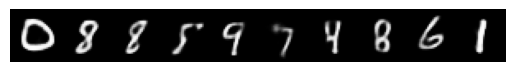

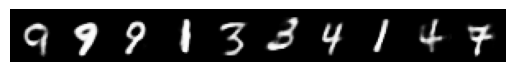

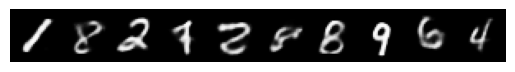

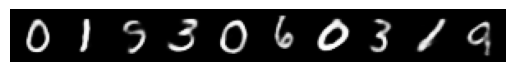

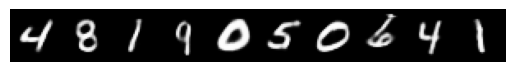

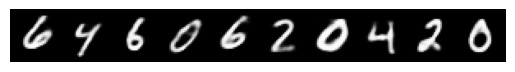

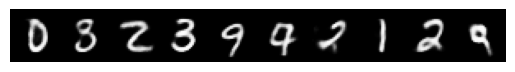

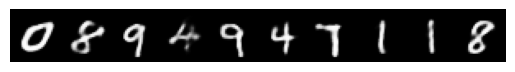

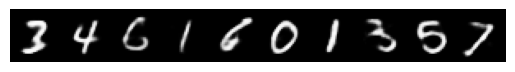

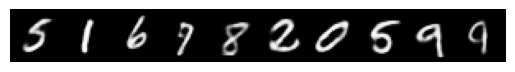

In [12]:
for i in range(10):
    vae_reporter(vae_model, xs[10*i: 10*(i+1)])

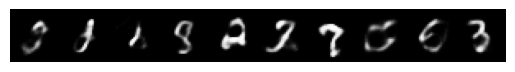

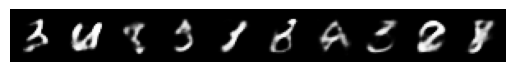

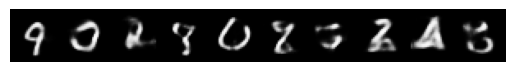

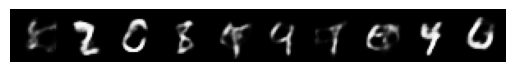

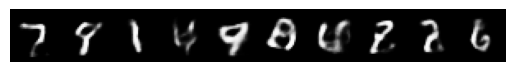

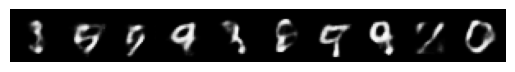

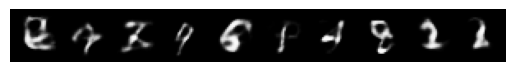

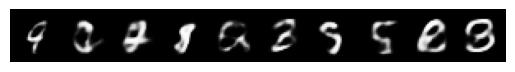

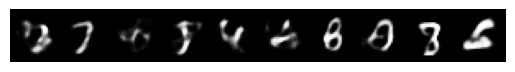

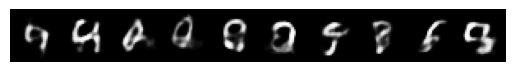

In [13]:
for i in range(10):
    vae_reporter(vae_model)

In [17]:

T = 1000
train = False
SAVE_PATH = f"/mnt/pml/DDPM_LATENT_EPOCH100_(VAE_EPOCH100_BETA0.02).model"
LOAD_PATH = f"/mnt/pml/diffusion_on_latent_space/latent_diffusion_epoch=20(vae_model_beta_lr=0.001--beta=1--epochs=20).model"


# Construct Unet
# The original ScoreNet expects a function with std for all the
# different noise levels, such that the output can be rescaled.
# Since we are predicting the noise (rather than the score), we
# ignore this rescaling and just set std=1 for all t.
mnist_unet = ScoreNet((lambda t: torch.ones(1).to(device)))

# Construct model
model = DDPM_LATENT(mnist_unet, vae_model, T=T).to(device)


if (train):
    # Parameters
    
    learning_rate = 1e-3
    epochs = 100
    
    # Construct optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Setup simple scheduler
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, 0.9999)
    
    # Call training loop
    ddpm_train(model, optimizer, scheduler, dataloader_train, 
          epochs=epochs, device=device, ema=True, per_epoch_callback=ddpm_latent_reporter)
    torch.save(model.state_dict(), SAVE_PATH)
else:
    model.load_state_dict(torch.load(LOAD_PATH, weights_only=True))
    
    

In [15]:
print("diffusion_fid: ", calculate_fid(dataloader_val, lambda n : model.sample(n)))

0it [00:00, ?it/s]

diffusion_fid:  0.1248575747013092


In [ ]:
#GRID SEARCH FOR Which Beta VAE is best
results=[]
grid_config= {"beta": [0.02, 0.5, 1, 2, 5]}
for beta in grid_config["beta"]:
    
    #LOAD Vae model with specific beta:
    vae_model = VAE().to(device)
    LOAD_PATH = f"/mnt/pml/grid_search_vae/vae_model_beta_lr=0.001--beta={beta}--epochs=20.model"
    SAVE_PATH = f"/mnt/pml/diffusion_on_latent_space/latent_diffusion_epoch=20(vae_model_beta_lr=0.001--beta={beta}--epochs=20).model"
    vae_model.load_state_dict(torch.load(LOAD_PATH, weights_only=True))
    #Train diffusion with this 
    mnist_unet = ScoreNet((lambda t: torch.ones(1).to(device)))
    model = DDPM_LATENT(mnist_unet, vae_model, T=1000).to(device)

    print("training: ", SAVE_PATH)
    learning_rate = 1e-3
    epochs = 20
    
    # Construct optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Setup simple scheduler
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, 0.9999)
    ddpm_train(model, optimizer, scheduler, dataloader_train, 
          epochs=epochs, device=device, ema=True, per_epoch_callback=ddpm_latent_reporter)
    torch.save(model.state_dict(), SAVE_PATH)

    fid_score = calculate_fid(dataloader_val, lambda n : model.sample(n))
    print("fid_score: ", fid_score)
    results.append((SAVE_PATH, fid_score))
    del(mnist_unet)
    del(model)
    del(vae_model)
    del(optimizer)
            




                

In [32]:
# Open a file in write mode ('w')
with open(f"/mnt/pml/diffusion_on_latent_space/results.csv", 'w') as f:
    f.write("path, fid\n")
    for item in results:
        f.write(f"{item[0]}, {item[1]}\n")

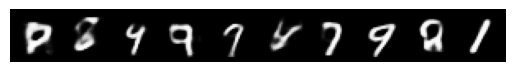

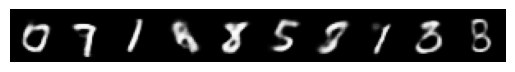

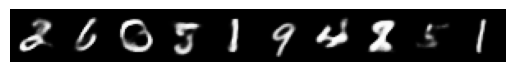

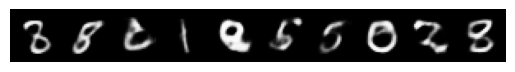

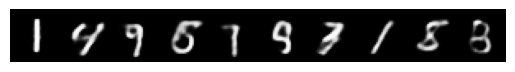

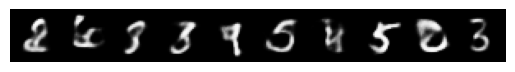

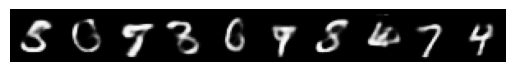

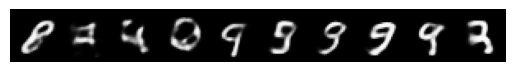

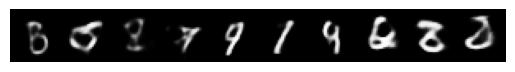

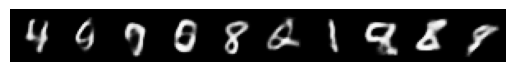

In [18]:
for i in range(10):
    ddpm_latent_reporter(model)

In [76]:
print("vae_fid: ", calculate_fid(dataloader_val, lambda n : vae_sample(vae_model, n) ))
print("diffusion_fid: ", calculate_fid(dataloader_val, lambda n : model.sample(n)))

    

0it [00:00, ?it/s]

vae_fid:  0.1336381882429123


0it [00:00, ?it/s]

diffusion_fid:  0.04939305782318115
